<a href="https://colab.research.google.com/github/ravindyaparami/Statistical-Learning-e20056/blob/main/E20056_GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [1]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

##Answer:

###Analysis

In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

# Download dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Listing contents of:", path)
print(os.listdir(path))

# Load dataset
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# Remove possible spaces in column names
df2.columns = df2.columns.str.strip()

# Features and outputs
X = df2[["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]]
Y = df2[["Y1", "Y2"]]

print(df2.head())
print(df2.describe())

# Check correlation between heating and cooling load
print("Correlation between Y1 and Y2:")
print(Y.corr())

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset
Listing contents of: /kaggle/input/eergy-efficiency-dataset
['ENB2012_data.csv']
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
               X1          X2          X3          X4         X5          X6  \
count  768.000000  768.000000  768.000000  768.000000  768.00000  768.000000   
mean     0.764167  671.708333  318.500000  176.604167    5.25000    3.500000   
std      0.105777   88.086116   43.626481   45.165950    1.75114    1.118763   
min      0.620000  514.500000  245.000000  110.250000    3.50000    2.000000   
25%   

In [3]:
corr = Y["Y1"].corr(Y["Y2"])
print("Correlation between heating load and cooling load:", corr)

Correlation between heating load and cooling load: 0.9758618134328573


For this dataset, heating load and cooling load have a very strong positive correlation.

This means that buildings with high heating load usually also tend to have high cooling load. Therefore, it is reasonable to explore whether both can be represented using one combined energy-load parameter.

###Method 1: Simple Single Combined Output

A simple way to create one output parameter is to take the average of heating and cooling load.

This represents the average energy demand of the building.

In [4]:
# Create single combined output
Y_combined = (Y["Y1"] + Y["Y2"]) / 2

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y_combined, test_size=0.2, random_state=42
)

# Scale input features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Define GP kernel
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel()

# Gaussian Process model
gp_combined = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

# Train model
gp_combined.fit(X_train_scaled, y_train)

# Predict
y_pred, y_std = gp_combined.predict(X_test_scaled, return_std=True)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Single combined output GP")
print("RMSE:", rmse)
print("R2 score:", r2)
print("Learned kernel:", gp_combined.kernel_)

Single combined output GP
RMSE: 0.6686698289706693
R2 score: 0.9953946226805164
Learned kernel: 316**2 * RBF(length_scale=4.93) + WhiteKernel(noise_level=0.341)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


###Method 2: PCA-Based Single Parameter

A better method is to use PCA on the two outputs Y
1 and Y
2
	​

PCA finds a new variable that captures the maximum variation in heating and cooling load.

Let the new single parameter be:

Z1=first principal component of [Y1 ,Y2]

If the first principal component explains most of the variance, then it means both heating load and cooling load can be approximately represented using one scalar value.

In [5]:
# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Scale X
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Scale Y before PCA
y_scaler = StandardScaler()
Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_test_scaled = y_scaler.transform(Y_test)

# Apply PCA to the two outputs
pca = PCA(n_components=2)
Y_train_pca = pca.fit_transform(Y_train_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# Use only the first principal component as the single output parameter
z_train = Y_train_pca[:, 0]

# GP model for the single latent parameter
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel()

gp_pca = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gp_pca.fit(X_train_scaled, z_train)

# Predict first principal component
z_pred = gp_pca.predict(X_test_scaled)

# Reconstruct Y1 and Y2 using only the first principal component
Y_pred_pca_scaled = np.zeros_like(Y_test_scaled)
Y_pred_pca_scaled[:, 0] = z_pred

Y_pred_scaled = pca.inverse_transform(Y_pred_pca_scaled)
Y_pred = y_scaler.inverse_transform(Y_pred_scaled)

# Evaluation for heating and cooling load
rmse_y1 = np.sqrt(mean_squared_error(Y_test["Y1"], Y_pred[:, 0]))
rmse_y2 = np.sqrt(mean_squared_error(Y_test["Y2"], Y_pred[:, 1]))

r2_y1 = r2_score(Y_test["Y1"], Y_pred[:, 0])
r2_y2 = r2_score(Y_test["Y2"], Y_pred[:, 1])

print("PCA-based single-parameter GP results")
print("Heating Load RMSE:", rmse_y1)
print("Heating Load R2:", r2_y1)

print("Cooling Load RMSE:", rmse_y2)
print("Cooling Load R2:", r2_y2)

print("Learned kernel:", gp_pca.kernel_)

Explained variance ratio:
[0.98815807 0.01184193]
PCA-based single-parameter GP results
Heating Load RMSE: 0.9677258571737241
Heating Load R2: 0.9910152603809506
Cooling Load RMSE: 1.5826347678840103
Cooling Load R2: 0.9729677584452299
Learned kernel: 316**2 * RBF(length_scale=9.66) + WhiteKernel(noise_level=0.00856)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


###Comparison with Separate GP Models

To properly decide whether a single-parameter GP is suitable, it should be compared with two separate GP models

In [6]:
def train_separate_gp(y, output_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)

    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel()

    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        random_state=42
    )

    gp.fit(X_train_scaled, y_train)
    y_pred = gp.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(output_name)
    print("RMSE:", rmse)
    print("R2 score:", r2)
    print("Learned kernel:", gp.kernel_)
    print()

train_separate_gp(Y["Y1"], "Separate GP for Heating Load")
train_separate_gp(Y["Y2"], "Separate GP for Cooling Load")

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Separate GP for Heating Load
RMSE: 0.4720929404878858
R2 score: 0.9978617631131703
Learned kernel: 316**2 * RBF(length_scale=5.22) + WhiteKernel(noise_level=0.129)

Separate GP for Cooling Load
RMSE: 1.344313605299266
R2 score: 0.9804960828674152
Learned kernel: 20.2**2 * RBF(length_scale=1.87) + WhiteKernel(noise_level=0.995)



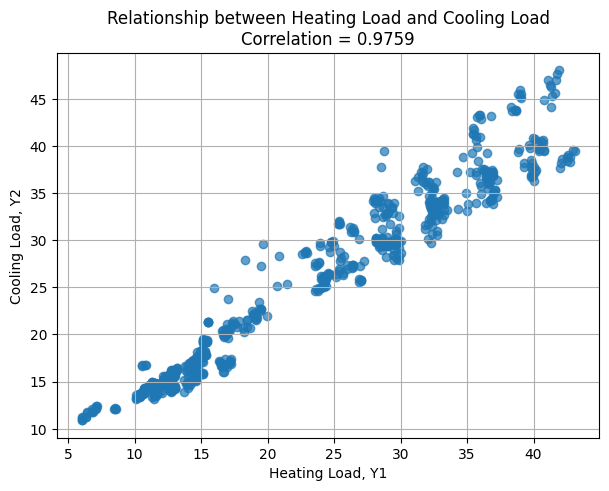

Correlation between Heating Load and Cooling Load: 0.9758618134328573
Explained variance ratio of PCA components:
PC1: 0.988158065547352
PC2: 0.011841934452647957


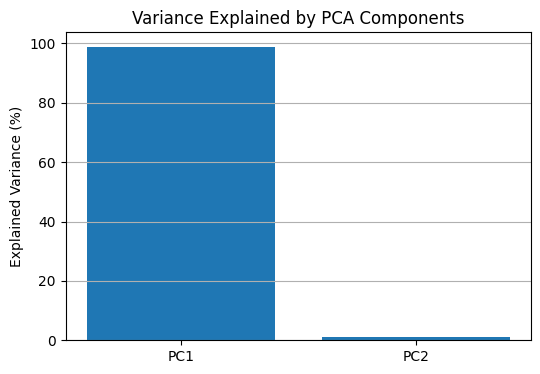

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned GP kernel:
316**2 * RBF(length_scale=9.66) + WhiteKernel(noise_level=0.00856)

PCA-based Single-Parameter GP Results
Heating Load RMSE: 0.9677258571737241
Heating Load R2: 0.9910152603809506
Cooling Load RMSE: 1.5826347678840103
Cooling Load R2: 0.9729677584452299


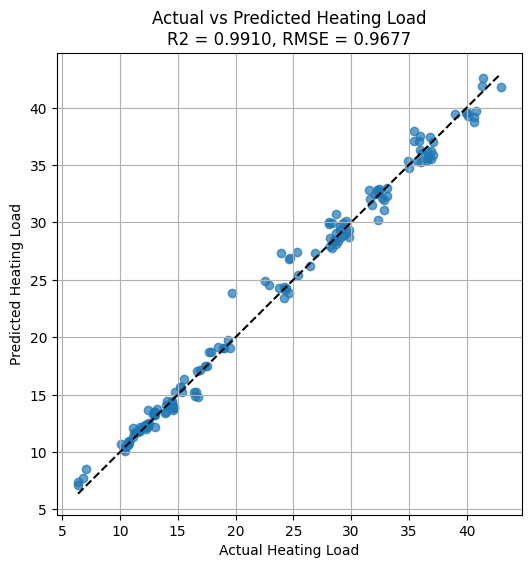

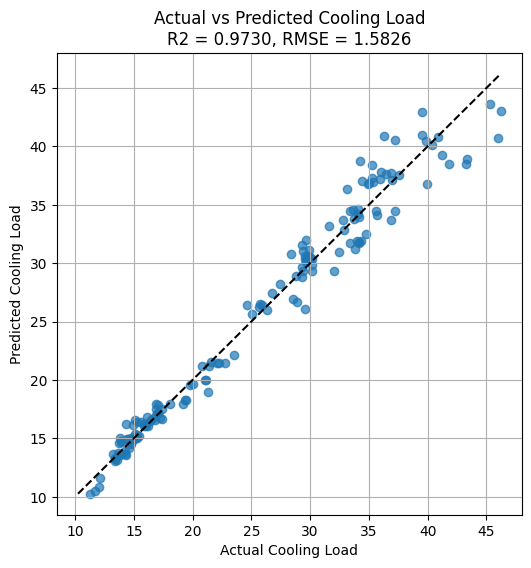

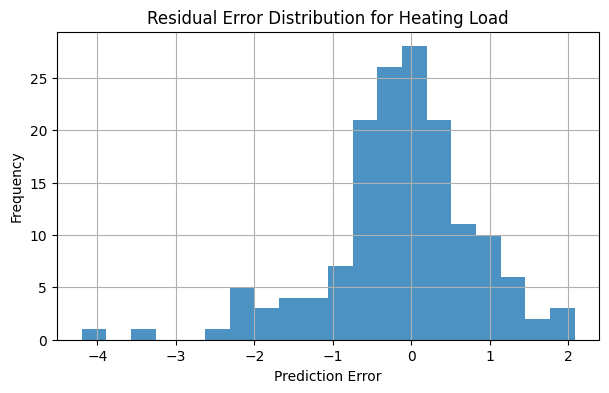

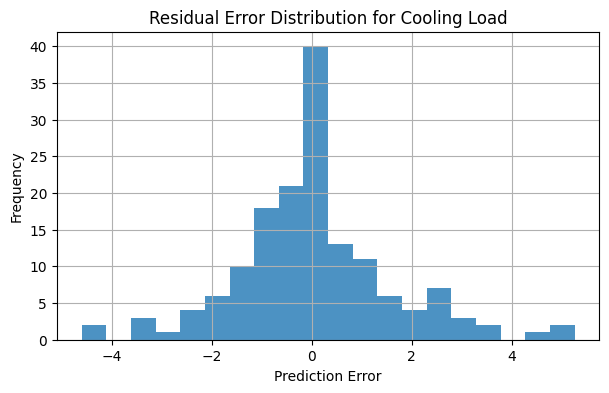

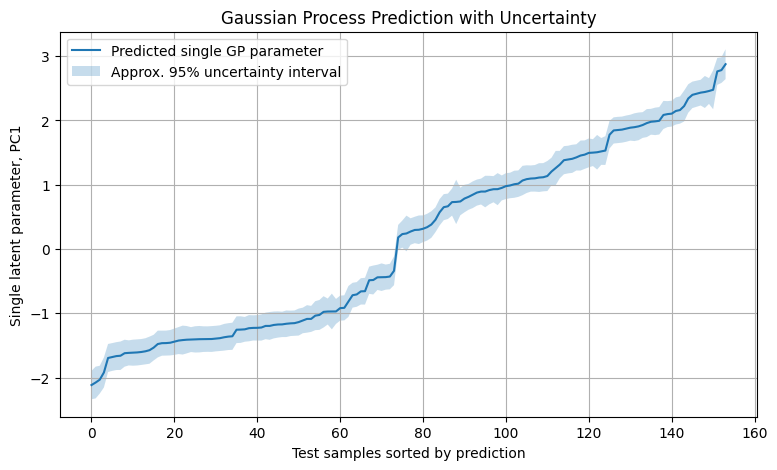

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

df2.columns = df2.columns.str.strip()

X = df2[["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]]
Y = df2[["Y1", "Y2"]]   # Y1 = Heating Load, Y2 = Cooling Load

# ------------------------------------------------------------
# 2. Plot relationship between Heating Load and Cooling Load
# ------------------------------------------------------------

corr = Y["Y1"].corr(Y["Y2"])

plt.figure(figsize=(7, 5))
plt.scatter(Y["Y1"], Y["Y2"], alpha=0.7)
plt.xlabel("Heating Load, Y1")
plt.ylabel("Cooling Load, Y2")
plt.title(f"Relationship between Heating Load and Cooling Load\nCorrelation = {corr:.4f}")
plt.grid(True)
plt.show()

print("Correlation between Heating Load and Cooling Load:", corr)

# ------------------------------------------------------------
# 3. Train-test split
# ------------------------------------------------------------

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Scale X
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Scale Y before PCA
y_scaler = StandardScaler()
Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_test_scaled = y_scaler.transform(Y_test)

# ------------------------------------------------------------
# 4. PCA on outputs Y1 and Y2
# ------------------------------------------------------------

pca = PCA(n_components=2)
Y_train_pca = pca.fit_transform(Y_train_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio of PCA components:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])

# Plot PCA explained variance
plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], explained_variance * 100)
plt.ylabel("Explained Variance (%)")
plt.title("Variance Explained by PCA Components")
plt.grid(axis="y")
plt.show()

# Use only first principal component as single output parameter
z_train = Y_train_pca[:, 0]

# ------------------------------------------------------------
# 5. Train Gaussian Process on the single PCA parameter
# ------------------------------------------------------------

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel()

gp_pca = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gp_pca.fit(X_train_scaled, z_train)

# Predict latent single parameter
z_pred, z_std = gp_pca.predict(X_test_scaled, return_std=True)

print("Learned GP kernel:")
print(gp_pca.kernel_)

# ------------------------------------------------------------
# 6. Reconstruct Y1 and Y2 from predicted single parameter
# ------------------------------------------------------------

Y_pred_pca_scaled = np.zeros_like(Y_test_scaled)

# Put predicted first principal component
Y_pred_pca_scaled[:, 0] = z_pred

# Second component is set to zero because we are using only one parameter
Y_pred_scaled = pca.inverse_transform(Y_pred_pca_scaled)

# Convert back to original scale
Y_pred = y_scaler.inverse_transform(Y_pred_scaled)

Y_pred_df = pd.DataFrame(
    Y_pred,
    columns=["Predicted Heating Load", "Predicted Cooling Load"],
    index=Y_test.index
)

# ------------------------------------------------------------
# 7. Evaluation
# ------------------------------------------------------------

rmse_y1 = np.sqrt(mean_squared_error(Y_test["Y1"], Y_pred[:, 0]))
rmse_y2 = np.sqrt(mean_squared_error(Y_test["Y2"], Y_pred[:, 1]))

r2_y1 = r2_score(Y_test["Y1"], Y_pred[:, 0])
r2_y2 = r2_score(Y_test["Y2"], Y_pred[:, 1])

print("\nPCA-based Single-Parameter GP Results")
print("Heating Load RMSE:", rmse_y1)
print("Heating Load R2:", r2_y1)
print("Cooling Load RMSE:", rmse_y2)
print("Cooling Load R2:", r2_y2)

# ------------------------------------------------------------
# 8. Actual vs Predicted plot for Heating Load
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(Y_test["Y1"], Y_pred[:, 0], alpha=0.7)

min_val = min(Y_test["Y1"].min(), Y_pred[:, 0].min())
max_val = max(Y_test["Y1"].max(), Y_pred[:, 0].max())

plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title(f"Actual vs Predicted Heating Load\nR2 = {r2_y1:.4f}, RMSE = {rmse_y1:.4f}")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 9. Actual vs Predicted plot for Cooling Load
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(Y_test["Y2"], Y_pred[:, 1], alpha=0.7)

min_val = min(Y_test["Y2"].min(), Y_pred[:, 1].min())
max_val = max(Y_test["Y2"].max(), Y_pred[:, 1].max())

plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title(f"Actual vs Predicted Cooling Load\nR2 = {r2_y2:.4f}, RMSE = {rmse_y2:.4f}")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 10. Residual error plots
# ------------------------------------------------------------

heating_error = Y_test["Y1"].values - Y_pred[:, 0]
cooling_error = Y_test["Y2"].values - Y_pred[:, 1]

plt.figure(figsize=(7, 4))
plt.hist(heating_error, bins=20, alpha=0.8)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Error Distribution for Heating Load")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(cooling_error, bins=20, alpha=0.8)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Error Distribution for Cooling Load")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 11. GP uncertainty plot for the single latent parameter
# ------------------------------------------------------------

# Sort points for clearer visualization
order = np.argsort(z_pred)

plt.figure(figsize=(9, 5))
plt.plot(z_pred[order], label="Predicted single GP parameter")
plt.fill_between(
    np.arange(len(z_pred)),
    z_pred[order] - 2 * z_std[order],
    z_pred[order] + 2 * z_std[order],
    alpha=0.25,
    label="Approx. 95% uncertainty interval"
)
plt.xlabel("Test samples sorted by prediction")
plt.ylabel("Single latent parameter, PC1")
plt.title("Gaussian Process Prediction with Uncertainty")
plt.legend()
plt.grid(True)
plt.show()

###Discussion

The heating load and cooling load are highly related because both depend on the same building geometry and design parameters. For example, relative compactness, surface area, wall area, roof area, overall height, glazing area, and glazing distribution affect both heating and cooling requirements.

Because of this relationship, it is possible to create a single output parameter that represents the overall thermal load of the building.

A simple combined parameter is:

Y
combined = (Y1+Y2)/2


This is easy to interpret because it represents the average load.

However, a more statistically meaningful method is PCA. If the first principal component explains almost all of the variance of Y
1 and Y
2, then one latent parameter is enough to describe most of the behavior of both heating load and cooling load.

In this case, the Gaussian Process model is trained as:

Z1=f(X)+ϵ

where Z
1 is the first principal component of heating and cooling load.
Then Y1 and Y2 can be approximately reconstructed from Z1.

###Limitations of Single-Parameter Modeling

Although the single-parameter GP model is possible, it has some limitations.

Heating load and cooling load are physically different quantities. A building design change may reduce heating load but increase cooling load. For example, increasing glazing area may increase solar heat gain. This can reduce heating demand in colder conditions, but increase cooling demand in warmer conditions.

Therefore, when Y
1 and Y
2 are combined into one parameter, some useful information is lost.

The single-parameter model is useful for estimating overall energy demand, but it is not the best choice if heating load and cooling load must be studied separately.

###Conclusion

A single-parameter Gaussian Process is possible for modeling the overall energy performance of the building, especially because heating load and cooling load are highly correlated. However, for more accurate and physically meaningful prediction, heating load and cooling load should preferably be modeled using two separate Gaussian Process models or a multi-output Gaussian Process model.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [10]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")
inspector.df=df2

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset
Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
['green_building_dataset.csv']
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2    

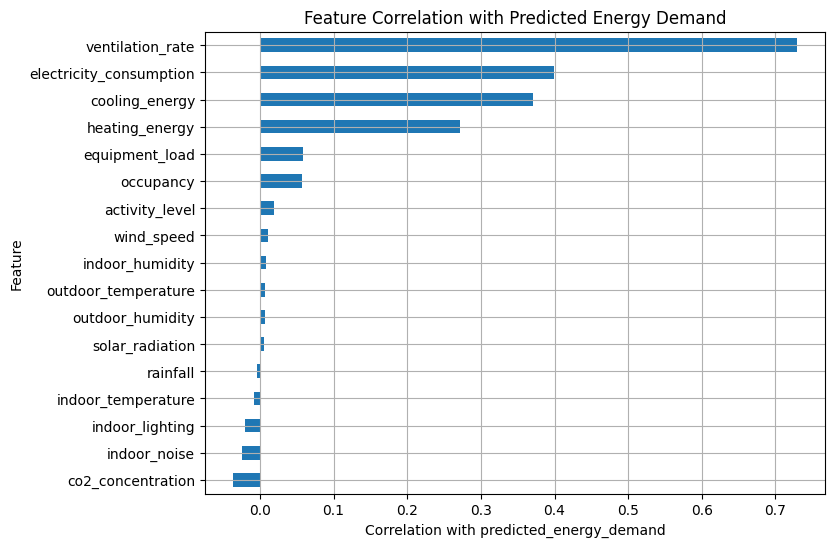

Linear Regression Results
Mean Absolute Error, MAE: 1.5082861893800692
Root Mean Squared Error, RMSE: 1.9112672487560094
R2 Score: 0.9608713649085102


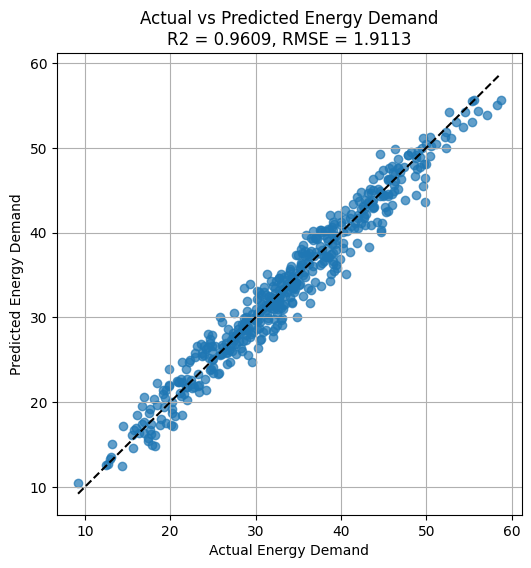

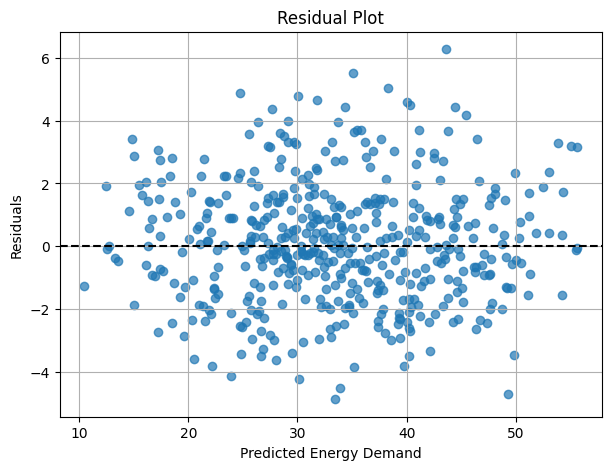

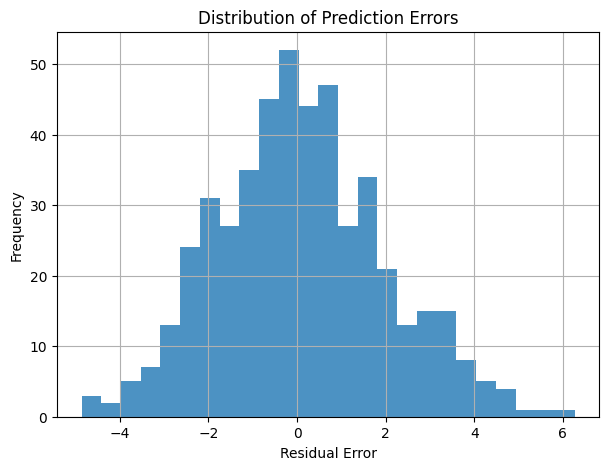

Most influential features:
                    Feature  Coefficient  Absolute Coefficient
13         ventilation_rate     7.185415              7.185415
10  electricity_consumption     4.173965              4.173965
12           cooling_energy     3.568578              3.568578
11           heating_energy     2.865182              2.865182
14           equipment_load     0.828751              0.828751
15                occupancy     0.664832              0.664832
0        indoor_temperature    -0.051094              0.051094
2         co2_concentration    -0.045749              0.045749
9                  rainfall     0.043882              0.043882
8                wind_speed     0.034780              0.034780
16           activity_level     0.034308              0.034308
6          outdoor_humidity     0.028226              0.028226
1           indoor_humidity    -0.024297              0.024297
3           indoor_lighting    -0.017078              0.017078
7           solar_radiation 

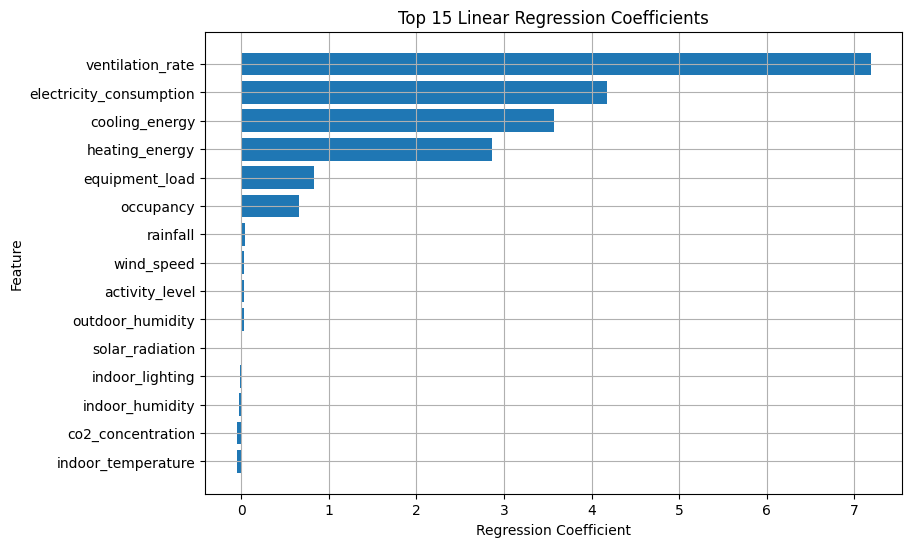

In [12]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Listing contents of:", path)
print(os.listdir(path))

df2 = pd.read_csv(path + "/green_building_dataset.csv")

# Clean column names
df2.columns = df2.columns.str.strip()

print(df2.head())
print(df2.info())
print(df2.describe())

# ------------------------------------------------------------
# 2. Define target
# ------------------------------------------------------------

target = "predicted_energy_demand"

if target not in df2.columns:
    raise ValueError(f"{target} is not found in the dataset columns.")

# ------------------------------------------------------------
# 3. Remove unsuitable columns
# ------------------------------------------------------------

# We remove the target itself.
# We also remove other predicted/target-type columns to avoid leakage.
drop_cols = [target]

for col in df2.columns:
    col_lower = col.lower()
    if col != target:
        if "predicted" in col_lower or "demand" in col_lower:
            drop_cols.append(col)

drop_cols = list(set(drop_cols))

print("Dropped columns:")
print(drop_cols)

X = df2.drop(columns=drop_cols)
y = df2[target]

# ------------------------------------------------------------
# 4. Handle missing values
# ------------------------------------------------------------

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data.drop(columns=[target])
y = data[target]

# ------------------------------------------------------------
# 5. Separate numeric and categorical columns
# ------------------------------------------------------------

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("Categorical features:")
print(categorical_features)

# ------------------------------------------------------------
# 6. Correlation analysis for numeric variables
# ------------------------------------------------------------

corr_data = data[numeric_features + [target]].corr()[target].sort_values(ascending=False)

print("Correlation with predicted_energy_demand:")
print(corr_data)

plt.figure(figsize=(8, 6))
corr_data.drop(target).sort_values().plot(kind="barh")
plt.xlabel("Correlation with predicted_energy_demand")
plt.ylabel("Feature")
plt.title("Feature Correlation with Predicted Energy Demand")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 7. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 8. Preprocessing and Linear Regression model
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ------------------------------------------------------------
# 9. Model evaluation
# ------------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("Mean Absolute Error, MAE:", mae)
print("Root Mean Squared Error, RMSE:", rmse)
print("R2 Score:", r2)

# ------------------------------------------------------------
# 10. Actual vs Predicted plot
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title(f"Actual vs Predicted Energy Demand\nR2 = {r2:.4f}, RMSE = {rmse:.4f}")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 11. Residual plot
# ------------------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Predicted Energy Demand")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 12. Residual histogram
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=25, alpha=0.8)
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 13. Extract regression coefficients
# ------------------------------------------------------------

# Get processed feature names
feature_names = []

if numeric_features:
    feature_names.extend(numeric_features)

if categorical_features:
    encoded_cat_names = model.named_steps["preprocessor"] \
        .named_transformers_["cat"] \
        .get_feature_names_out(categorical_features)
    feature_names.extend(encoded_cat_names)

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Absolute Coefficient", ascending=False)

print("Most influential features:")
print(coef_df.head(15))

# Plot top coefficients
plt.figure(figsize=(9, 6))
top_coef = coef_df.head(15).sort_values(by="Coefficient")
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Linear Regression Coefficients")
plt.grid(True)
plt.show()

###Parameter Selection Justification

The input parameters were selected from the available building and environmental variables after excluding unsuitable columns.

The target variable is:

predicted_energy_demand

Columns such as predicted_comfort_index or other predicted output-type variables should not be used as input variables because they are also derived or predicted quantities. Using them may give an artificially high accuracy and reduce the fairness of the model.

The suitable parameters are selected based on three ideas:

1. Physical relevance

Building energy demand is usually affected by indoor conditions, outdoor environment, occupancy, ventilation, lighting, and building design parameters.

2. Statistical relationship

The correlation plot shows which numerical variables have strong positive or negative relationships with predicted_energy_demand.

3. Model interpretability

Linear regression is useful because each coefficient shows how one parameter affects the energy demand when other variables are kept constant.

###Graphs

####Correlation Graph

The correlation graph shows which parameters are most linearly related to energy demand.

A high positive correlation means that when that parameter increases, energy demand also tends to increase.

A high negative correlation means that when that parameter increases, energy demand tends to decrease.

Variables with very low correlation may have weak linear influence on the target.

####Actual vs Predicted Graph

The actual vs predicted graph is used to check model accuracy.

If the linear regression model performs well, the points should lie close to the dashed diagonal line.

The diagonal line represents:

Actual value=Predicted value

If points are widely scattered away from the line, the linear model is not capturing the relationship well.

####Residual Plot

The residual is:

Residual=y actual−y predicted

The residual plot is used to check whether the linear regression assumptions are reasonable.

A good residual plot should show points randomly scattered around zero.

If the residual plot shows a curve or pattern, that means the relationship may be nonlinear.

####Coefficient Plot

The coefficient plot shows which variables have the largest influence on the model.

A positive coefficient means that increasing the variable increases predicted energy demand.

A negative coefficient means that increasing the variable decreases predicted energy demand.

The magnitude of the coefficient shows the strength of the influence.

###Discussion

The results can be discussed using the printed values of MAE, RMSE, and R
2.

The coefficient of determination is:
R
2

If R
2 is close to 1, the model explains most of the variation in energy demand.

If R
2 is low, the linear model is not sufficient, and the relationship between building parameters and energy demand may be nonlinear.

Linear regression is a good first model because it is simple, interpretable, and gives a clear mathematical relationship between parameters and energy demand.

However, green building energy demand is often influenced by nonlinear interactions. For example, temperature, humidity, occupancy, ventilation, and building material properties may interact with each other. Therefore, even if linear regression gives reasonable results, more advanced models such as polynomial regression, random forest regression, gradient boosting, or neural networks may perform better.

###Conclusion

Linear regression is useful as an interpretable baseline model for predicting building energy demand. It can identify the most influential parameters, but its accuracy depends on how linear the relationship is between the selected variables and predicted_energy_demand.